In [1]:
# ============================================================================
# ASKAP FLYEYE - MAXIMUM REDSHIFT DETECTION ANALYSIS
# ============================================================================
# Calculate the maximum redshift at which ASKAP can detect FRBs with L_max = 10^16 Jy kpc²

import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM



DETECTION RESULTS:

Maximum detectable redshift: z_max ≈ 1.632
SNR at z_max: 10.20

Crossover redshift (SNR = 10): z_cross ≈ 1.652
SNR at crossover: 9.82

>>> After z > 1.652, SNR drops below 10 (non-detectable)

Detailed Redshift Analysis:
z        d_L (Mpc)       S0_frb (mJy)       S_nu_low (mJy)     SNR       
--------------------------------------------------------------------------------
0.09     411.9           5.4078e+07         5.4078e+07         21254.45  
0.49     2768.4          8.7542e+05         8.7542e+05         344.07    
0.99     6534.1          1.1764e+05         1.1764e+05         46.24     
1.49     10833.2         3.4200e+04         3.4200e+04         13.44     
1.99     15463.4         1.3978e+04         1.3978e+04         5.49      
2.49     20322.0         6.9332e+03         6.9332e+03         2.72      
2.99     25351.2         3.8968e+03         3.8968e+03         1.53      
3.99     35787.9         1.5634e+03         1.5634e+03         0.61      
4.99     46

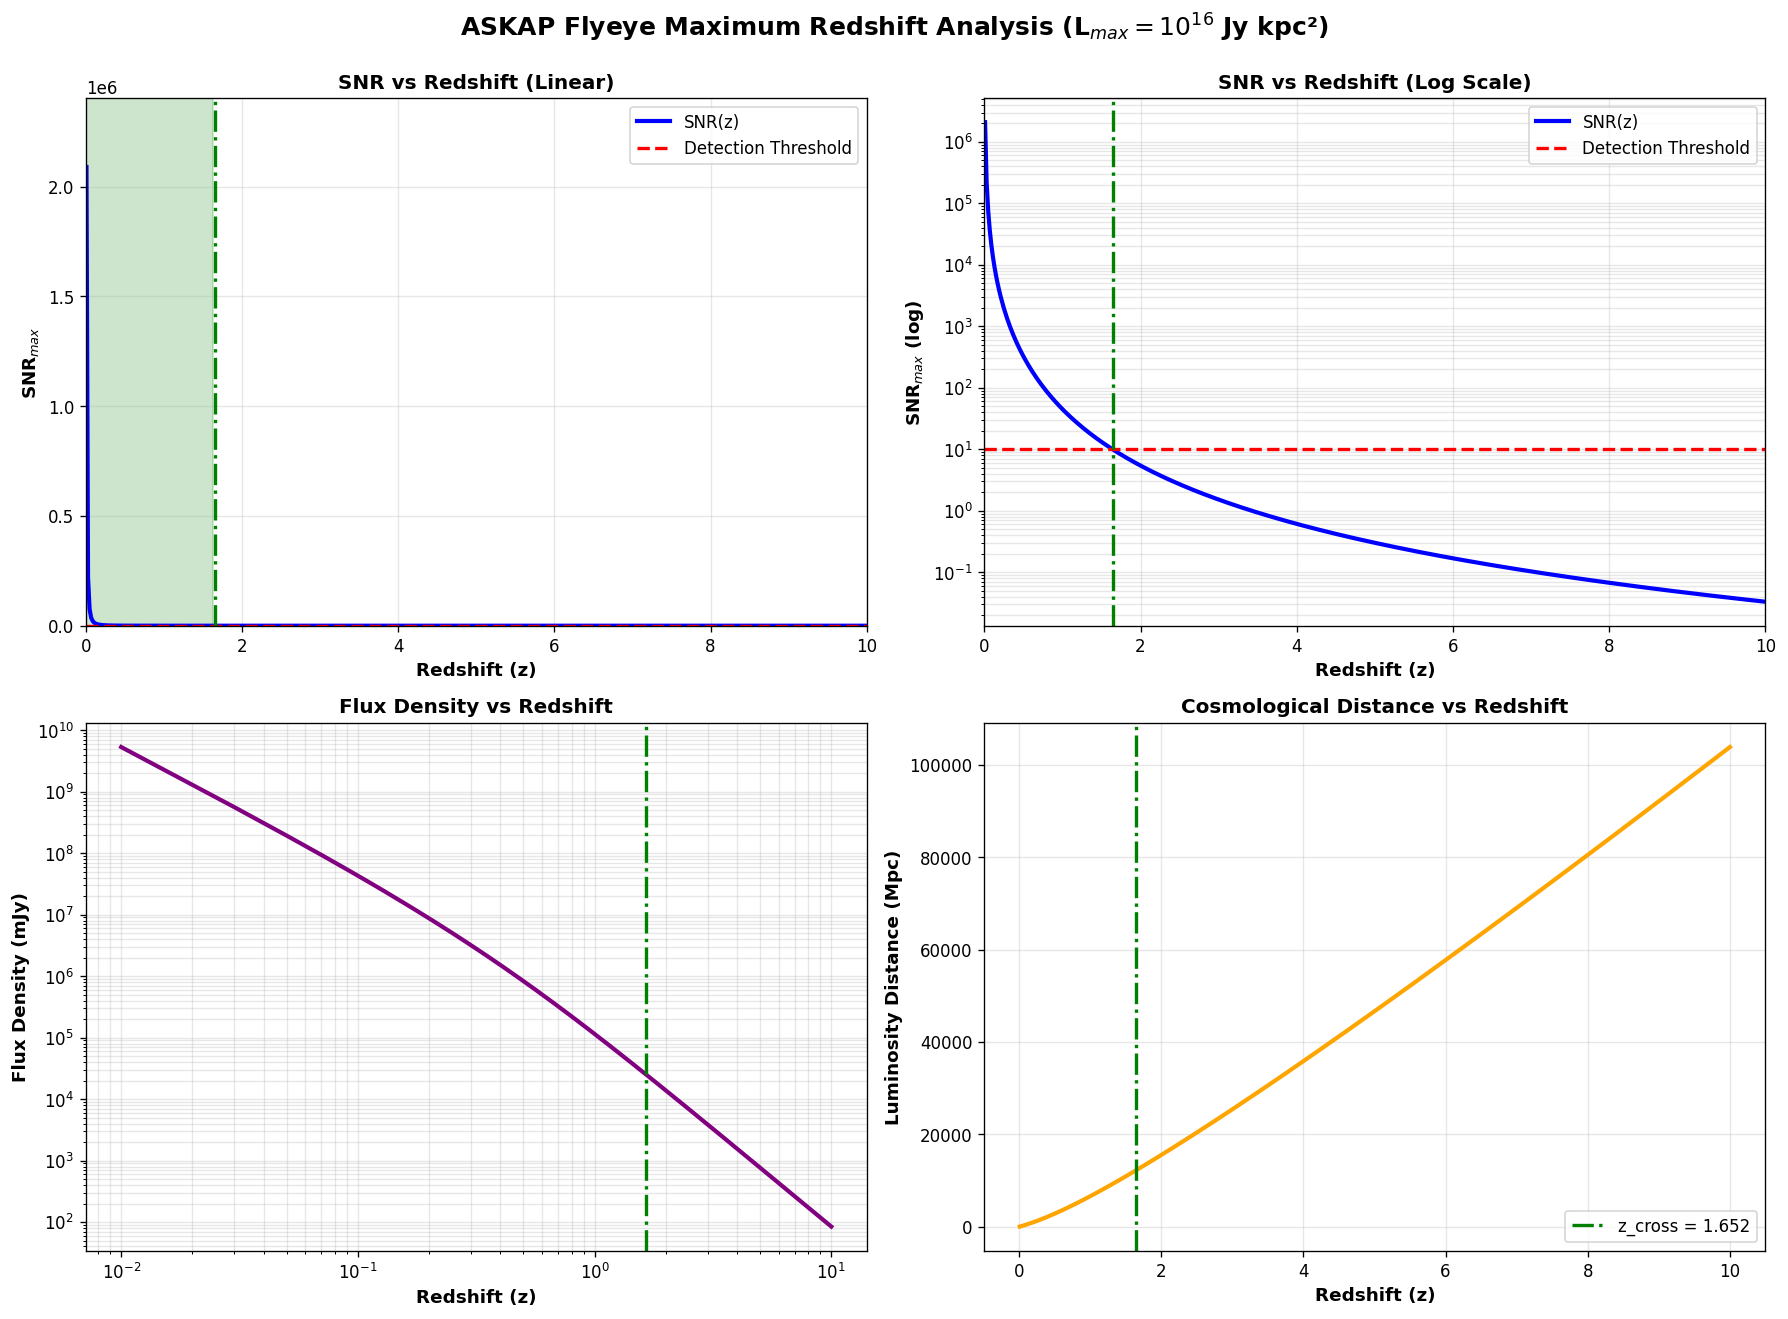


SUMMARY
Maximum SNR: 2089205.18 at z = 0.010
SNR range: 0.0331 to 2089205.18
Flux range: 8.4305e+01 to 5.3156e+09 mJy
Distance range: 43.2 to 103842.7 Mpc

>>> KEY RESULT: ASKAP can detect L=10^16 Jy kpc² FRBs up to z ≈ 1.652


In [2]:

# ============================================================================
# 1. TELESCOPE PARAMETERS
# ============================================================================
D = 12              # Diameter in meters
G0 = 0.035          # Beam gain
nu0 = 1.4e9         # Reference frequency in Hz
Np = 2              # Number of polarizations
Trec = 70           # Receiver temperature (K)
Tsky = 3            # Sky temperature (K)
BW = 336e6          # Bandwidth (Hz)
nu_cen = 1.32e9     # Central frequency (Hz)
nu_min = nu_cen - BW / 2
nu_max = nu_cen + BW / 2
t = 0.001           # Integration time in seconds
c = 3.0e8           # Speed of light

# FRB Parameters
L_max = 1e16        # Maximum luminosity (Jy kpc²)
alpha_intrinsic = 0 # Flat spectral index
wi = 0.001          # Intrinsic width (seconds)



# ============================================================================
# 2. FUNCTION DEFINITIONS
# ============================================================================
def gaussian_beam_gain(nu, G0, theta, D, c):
    """Gaussian beam gain with frequency dependence"""
    coeff = (theta**2 * D**2 * 2.355**2) / (2 * 1.22**2 * c**2)
    return G0 * np.exp(-coeff * nu**2)

def SNR(S, t, G, BW, Np, Trec, Tsky):
    """Calculate Signal-to-Noise Ratio"""
    return S * G * np.sqrt(BW * t * Np) / (Trec + Tsky)

# ============================================================================
# 3. SETUP COSMOLOGY AND REDSHIFT ARRAY
# ============================================================================
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
z_array_analysis = np.linspace(0.01, 10, 500)

# ============================================================================
# 4. MAIN ANALYSIS: CALCULATE SNR VS REDSHIFT
# ============================================================================
snr_max_array = []
S0_frb_array = []
S_nu_low_array = []
dl_array = []

for z in z_array_analysis:
    # Luminosity distance
    dl_mpc = cosmo.luminosity_distance(z).value
    dl_kpc = dl_mpc * 1000
    dl_array.append(dl_kpc)
    
    # Observer-frame width (redshifted)
    wi_z = wi * (1 + z)
    
    # Flux density at reference frequency
    S0_frb = L_max / (dl_kpc**2 * (1 + z)**(1 + alpha_intrinsic)) 
    S0_frb_array.append(S0_frb)
    
    # Flux at minimum frequency
    S_nu_low = S0_frb * (nu_min / nu0)**alpha_intrinsic
    S_nu_low_array.append(S_nu_low)
    
    # Beam gain at on-axis position
    G_max = gaussian_beam_gain(nu0, G0, 0, D, c)
    
    # Calculate SNR
    snr_max = SNR(S_nu_low, t, G_max, BW, Np, Trec, Tsky)
    snr_max_array.append(snr_max)

# Convert to arrays
snr_max_array = np.array(snr_max_array)
S0_frb_array = np.array(S0_frb_array)
S_nu_low_array = np.array(S_nu_low_array)
dl_array = np.array(dl_array)

# ============================================================================
# 5. FIND MAXIMUM DETECTABLE REDSHIFT
# ============================================================================
detection_threshold = 10
mask_detectable = snr_max_array > detection_threshold
z_detectable = z_array_analysis[mask_detectable]

if np.any(mask_detectable):
    idx_max = np.where(mask_detectable)[0][-1]
    z_max = z_detectable[-1]
    snr_at_z_max = snr_max_array[idx_max]
    
    if len(z_detectable) < len(z_array_analysis):
        idx_crossover = np.where(~mask_detectable)[0][0]
        z_crossover = z_array_analysis[idx_crossover]
        snr_at_crossover = snr_max_array[idx_crossover]
    else:
        z_crossover = z_array_analysis[-1]
        snr_at_crossover = snr_max_array[-1]
else:
    z_max = 0
    z_crossover = z_array_analysis[0]

# ============================================================================
# 6. PRINT RESULTS
# ============================================================================
print(f"\n{'='*80}")
print("DETECTION RESULTS:")
print(f"{'='*80}")
print(f"\nMaximum detectable redshift: z_max ≈ {z_max:.3f}")
print(f"SNR at z_max: {snr_at_z_max:.2f}")
print(f"\nCrossover redshift (SNR = 10): z_cross ≈ {z_crossover:.3f}")
print(f"SNR at crossover: {snr_at_crossover:.2f}")
print(f"\n>>> After z > {z_crossover:.3f}, SNR drops below 10 (non-detectable)")
print(f"{'='*80}\n")

# Detailed table
print(f"Detailed Redshift Analysis:")
print(f"{'z':<8} {'d_L (Mpc)':<15} {'S0_frb (mJy)':<18} {'S_nu_low (mJy)':<18} {'SNR':<10}")
print("-"*80)

key_z_values = [0.1, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]

for z_check in key_z_values:
    if z_check <= z_array_analysis[-1]:
        idx = np.argmin(np.abs(z_array_analysis - z_check))
        z_val = z_array_analysis[idx]
        dl_val = dl_array[idx]
        S0_val = S0_frb_array[idx]
        Slow_val = S_nu_low_array[idx]
        snr_val = snr_max_array[idx]
        
        marker = " ← CROSSOVER" if abs(snr_val - 10) < 0.5 else ""
        print(f"{z_val:<8.2f} {dl_val/1000:<15.1f} {S0_val*1e3:<18.4e} {Slow_val*1e3:<18.4e} {snr_val:<10.2f}{marker}")

# ============================================================================
# 7. PLOTS
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 11), dpi=120)

# Plot 1: SNR vs Redshift (linear)
ax = axes[0, 0]
ax.plot(z_array_analysis, snr_max_array, 'b-', linewidth=2.5, label='SNR(z)')
ax.axhline(10, color='red', linestyle='--', linewidth=2, label='Detection Threshold')
ax.axvline(z_crossover, color='green', linestyle='-.', linewidth=2)
ax.fill_between(z_array_analysis, 0, max(snr_max_array)*1.2, 
                where=(snr_max_array > 10), alpha=0.2, color='green')
ax.set_xlabel('Redshift (z)', fontsize=11, fontweight='bold')
ax.set_ylabel('SNR$_{max}$', fontsize=11, fontweight='bold')
ax.set_title('SNR vs Redshift (Linear)', fontsize=12, fontweight='bold')
ax.set_ylim([0, max(snr_max_array) * 1.15])
ax.set_xlim([0, 10])
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)

# Plot 2: SNR vs Redshift (log)
ax = axes[0, 1]
ax.semilogy(z_array_analysis, snr_max_array, 'b-', linewidth=2.5, label='SNR(z)')
ax.axhline(10, color='red', linestyle='--', linewidth=2, label='Detection Threshold')
ax.axvline(z_crossover, color='green', linestyle='-.', linewidth=2)
ax.set_xlabel('Redshift (z)', fontsize=11, fontweight='bold')
ax.set_ylabel('SNR$_{max}$ (log)', fontsize=11, fontweight='bold')
ax.set_title('SNR vs Redshift (Log Scale)', fontsize=12, fontweight='bold')
ax.set_xlim([0, 10])
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3, which='both')

# Plot 3: Flux Density vs Redshift
ax = axes[1, 0]
ax.loglog(z_array_analysis, S_nu_low_array * 1e3, 'purple', linewidth=2.5)
ax.axvline(z_crossover, color='green', linestyle='-.', linewidth=2)
ax.set_xlabel('Redshift (z)', fontsize=11, fontweight='bold')
ax.set_ylabel('Flux Density (mJy)', fontsize=11, fontweight='bold')
ax.set_title('Flux Density vs Redshift', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, which='both')

# Plot 4: Luminosity Distance vs Redshift
ax = axes[1, 1]
ax.plot(z_array_analysis, dl_array / 1000, 'orange', linewidth=2.5)
ax.axvline(z_crossover, color='green', linestyle='-.', linewidth=2, 
           label=f'z_cross = {z_crossover:.3f}')
ax.set_xlabel('Redshift (z)', fontsize=11, fontweight='bold')
ax.set_ylabel('Luminosity Distance (Mpc)', fontsize=11, fontweight='bold')
ax.set_title('Cosmological Distance vs Redshift', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle('ASKAP Flyeye Maximum Redshift Analysis (L$_{max} = 10^{16}$ Jy kpc²)', 
             fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print(f"\n{'='*80}")
print("SUMMARY")
print(f"{'='*80}")
print(f"Maximum SNR: {snr_max_array.max():.2f} at z = {z_array_analysis[snr_max_array.argmax()]:.3f}")
print(f"SNR range: {snr_max_array[-1]:.4f} to {snr_max_array.max():.2f}")
print(f"Flux range: {S_nu_low_array.min()*1e3:.4e} to {S_nu_low_array.max()*1e3:.4e} mJy")
print(f"Distance range: {dl_array.min()/1000:.1f} to {dl_array.max()/1000:.1f} Mpc")
print(f"\n>>> KEY RESULT: ASKAP can detect L=10^16 Jy kpc² FRBs up to z ≈ {z_crossover:.3f}")
print(f"{'='*80}")